# Similitud coseno


La similitud coseno es una medida de la similitud existente entre dos vectores en un espacio que posee un producto interior con el que se evalúa el valor del coseno del ángulo comprendido entre ellos. Esta función trigonométrica proporciona un valor igual a 1 si el ángulo comprendido es cero, es decir si ambos vectores apuntan a un mismo lugar. Cualquier ángulo existente entre los vectores, el coseno arrojaría un valor inferior a uno. Si los vectores fuesen ortogonales el coseno se anularía, y si apuntasen en sentido contrario su valor sería -1. De esta forma, el valor de esta métrica se encuentra entre -1 y 1, es decir en el intervalo cerrado [-1,1].

Esta distancia se emplea frecuentemente en la búsqueda y recuperación de información representando las palabras (o documento) en un espacio vectorial. En minería de textos se aplica la similitud coseno con el objeto de establecer una métrica de semejanza entre textos. En minería de datos se suele emplear como un indicador de cohesión de clústeres de textos. La similitud coseno no debe ser considerada como una métrica debido a que no cumple la desigualdad triangular.

Un enfoque comúnmente utilizado para unir documentos similares se basa en contar el número máximo de palabras comunes entre los documentos.

Pero este enfoque tiene un defecto inherente. Es decir, a medida que aumenta el tamaño del documento, el número de palabras comunes tiende a aumentar incluso si los documentos hablan de diferentes temas.

La similitud del coseno ayuda a superar este defecto fundamental en el enfoque de "distancia de palabras comunes" o distancia euclidiana.


# ¿Cual es la ventaja?


La similitud de coseno es una métrica utilizada para determinar qué tan similares son los documentos, independientemente de su tamaño.

Matemáticamente, mide el coseno del ángulo entre dos vectores proyectados en un espacio multidimensional. En este contexto, los dos vectores son matrices que contienen la frecuencia  de palabras de dos documentos.

Como métrica de similitud, ¿cómo difiere el algoritmo del número de palabras comunes?

Cuando se traza en un espacio multidimensional, donde cada dimensión corresponde a una palabra en el documento, la similitud del coseno captura la orientación (el ángulo) de los documentos y no la magnitud. Si se desea la magnitud, se puede calcular la distancia euclidiana en su lugar.

La similitud  coseno es ventajosa porque incluso si los dos documentos similares están muy separados por la distancia euclidiana debido al tamaño (como, la palabra 'grillo' apareció 50 veces en un documento y 10 veces en otro) aún podrían tener un ángulo más pequeño entre ellos. Cuanto menor es el ángulo, mayor es la similitud.

# Ejemplo de similitud de coseno

Supongamos que se tiene 3 documentos basados en un par de  jugadores de cricket estrella: Sachin, Tendulkar y Dhoni. Dos de los documentos (A) y (B) son de las páginas de wikipedia en los respectivos jugadores y el tercer documento (C) es un fragmento más pequeño de la página de Wikipedia de Dhoni.

<img src='cs2.png'>


Como se puede ver, los tres documentos están conectados por un tema común: el juego de Cricket.

Nuestro objetivo es estimar cuantitativamente la similitud entre los documentos. Para facilitar la comprensión, consideremos solo las 3 palabras más comunes entre los documentos: 'Dhoni', 'Sachin' y 'Cricket'. Es de esperar que  A y  C , es decir, los dos documentos en Dhoni tengan una mayor similitud con  A y  B , porque,  C es esencialmente un fragmento del de  A. Sin embargo, si vamos por el número de palabras comunes, los dos documentos más grandes tendrán las palabras más comunes y, por lo tanto, se considerán más similares, que es exactamente lo que queremos evitar. Los resultados serían más congruentes cuando utilizamos el puntaje de similitud de coseno para evaluar la similitud.


Proyectemos los documentos en un espacio tridimensional, donde cada dimensión es un recuento de frecuencia de: 'Sachin', 'Dhoni' o 'Cricket'. Cuando se traza en este espacio, los 3 documentos aparecerían algo así.

<img src='cs3.png'>

Como se puede ver, el Documento de  Dhoni_Small y el Documento Dhoni principal están orientados más juntos en el espacio tridimensional, a pesar de que están muy separados por magnitud.

Resulta que cuanto más cerca están los documentos por ángulo, mayor es la similitud de coseno.

<img src='fcs.png'>


A medida que incluye más palabras del documento, es más difícil visualizar un espacio dimensional superior. Pero puede calcular directamente la similitud del coseno utilizando esta fórmula matemática.

In [1]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
%config IPCompleter.greedy=True


In [9]:
vec1 = np.array([[1,1,0,1,1]])
vec2 = np.array([[0,1,0,1,1]])

In [10]:
print(cosine_similarity(vec1, vec2))

[[0.8660254]]


In [20]:
# Cargar el dataset
try:
    df = pd.read_csv('dataset_sintetico_5000_ampliado.csv')
    print("Dataset cargado correctamente.")
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo 'datasetTexto.csv' esté en la misma carpeta.")

# Guardar todos los textos de la columna Comentario_Reaccion en la lista twits
twits = df['Texto'].astype(str).tolist()

print("Se cargaron", len(twits), "comentarios en la lista 'twits'.")

Dataset cargado correctamente.
Se cargaron 200 comentarios en la lista 'twits'.


In [22]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Lista básica de stopwords en español
spanish_stopwords = [
    "de","la","que","el","en","y","a","los","del","se","las","por","un","para",
    "con","no","una","su","al","lo","como","más","pero","sus","le","ya","o",
    "este","sí","porque","esta","entre","cuando","muy","sin","sobre","también",
    "me","hasta","hay","donde","quien","desde","todo","nos","durante","todos",
    "uno","les","ni","contra","otros","ese","eso","ante","ellos","e","esto",
    "mí","antes","algunos","qué","unos","yo","otro","otras"
]

# Crear la matriz de frecuencias
count_vectorizer = CountVectorizer(stop_words=spanish_stopwords)
matrix = count_vectorizer.fit_transform(twits)

# Convertir a matriz legible
data_matrix = matrix.todense()
frecuencias = pd.DataFrame(
    data_matrix,
    columns=count_vectorizer.get_feature_names_out(),
    index=[f"tw{i+1}" for i in range(len(twits))]
)

frecuencias


,10,68,abandona,abrir,actor,actuación,actuar,adaptación,adaptar,admirable,...,ángel,épica,época,épocas,éramos,ética,éxito,ídolo,última,única
tw1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tw2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tw3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tw4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
tw5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tw196,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tw197,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tw198,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tw199,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
frecuencias.loc["tw1":"tw2", "17":"batallon"]

,68,abandona,abrir,actor,actuación,actuar,adaptación,adaptar,admirable,agradece,...,asistencia,así,atacan,atención,aterrador,autor,añade,banda,barroco,base
tw1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tw2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
frecuencias.loc['tw1',:].head(40)

10            0
68            0
abandona      0
abrir         0
actor         0
actuación     0
actuar        0
adaptación    0
adaptar       0
admirable     0
agradece      0
aguja         0
aire          0
alfombra      0
algoritmo     0
aliados       0
alma          0
alto          0
alza          0
alzar         0
ama           0
amantes       0
ambición      0
ambos         0
ancla         0
ansiedad      0
antaño        0
apenas        0
aplausos      0
apoyan        0
apoyas        0
apoyo         0
arma          0
arregla       0
arreglarlo    0
arrogancia    0
arte          0
artesanal     0
artesano      0
artistas      0
Name: tw1, dtype: int64

In [25]:
salida = cosine_similarity(frecuencias, frecuencias)

In [26]:
salida

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.13363062, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.13363062, 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [28]:
count_vectorizer.get_feature_names_out()

array(['10', '68', 'abandona', 'abrir', 'actor', 'actuación', 'actuar',
       'adaptación', 'adaptar', 'admirable', 'agradece', 'aguja', 'aire',
       'alfombra', 'algoritmo', 'aliados', 'alma', 'alto', 'alza',
       'alzar', 'ama', 'amantes', 'ambición', 'ambos', 'ancla',
       'ansiedad', 'antaño', 'apenas', 'aplausos', 'apoyan', 'apoyas',
       'apoyo', 'arma', 'arregla', 'arreglarlo', 'arrogancia', 'arte',
       'artesanal', 'artesano', 'artistas', 'asistencia', 'así', 'atacan',
       'atención', 'aterrador', 'autor', 'añade', 'banda', 'barroco',
       'base', 'bello', 'blindan', 'bots', 'brecha', 'brillante',
       'brutal', 'buena', 'bueno', 'cada', 'calle', 'calles', 'cambia',
       'cambio', 'cambios', 'canales', 'cansaremos', 'carteles', 'casa',
       'casting', 'causa', 'cdmx', 'celebra', 'celular', 'censura',
       'chispa', 'ciencia', 'cine', 'cinematográfica', 'cineteca',
       'ciudadanos', 'clave', 'clerval', 'clásico', 'cobertura',
       'coherente', 'cole

In [29]:
count_vectorizer.vocabulary_

{'jóvenes': 308,
 'exigen': 214,
 'seguridad': 522,
 'sólo': 554,
 'retórica': 504,
 'política': 458,
 'mexicoprotesta': 361,
 'versión': 607,
 'toro': 574,
 'es': 189,
 'increíblemente': 284,
 'emotiva': 179,
 'lágrimas': 327,
 'garantizadas': 238,
 'gdtfrankenstein': 240,
 'dicen': 149,
 'somos': 543,
 'pocos': 455,
 'ruido': 513,
 'hacemos': 258,
 'somosmas': 544,
 'necesito': 392,
 'ir': 301,
 'alfombra': 13,
 'roja': 510,
 'gdt': 239,
 'ídolo': 637,
 'estética': 209,
 'gótica': 252,
 'cdmx': 70,
 'siempre': 532,
 'fácil': 236,
 'culpar': 118,
 'bots': 52,
 'escuchar': 195,
 'calle': 59,
 'nosoyunbot': 399,
 'obra': 409,
 'maestra': 330,
 'debe': 126,
 'verse': 606,
 'pantalla': 426,
 'grande': 249,
 'sonido': 546,
 'vital': 622,
 'enfrentamientos': 184,
 'escalaron': 191,
 'piden': 449,
 'diálogo': 161,
 'represión': 498,
 'perfecto': 442,
 'maratón': 338,
 'terror': 564,
 'melancólico': 350,
 'fin': 222,
 'semana': 524,
 'grito': 250,
 'futuro': 235,
 'están': 208,
 'robando': 50

In [11]:
frecuencias.columns.tolist()

['17',
 '22',
 '230',
 'al',
 'aldama',
 'armas',
 'arribó',
 'autoridades',
 'batallón',
 'cabo',
 'campaña',
 'canje',
 'chapo',
 'ciudad',
 'civil',
 'con',
 'contingente',
 'coordinación',
 'culiacán',
 'de',
 'defensa',
 'del',
 'despensa',
 'despliega',
 'distintos',
 'ejércitoyfam',
 'el',
 'elementos',
 'en',
 'episodio',
 'este',
 'fuego',
 'guzmán',
 'hasta',
 'hijos',
 'infantería',
 'jornada',
 'jueves',
 'la',
 'liberación',
 'llevaron',
 'los',
 'luego',
 'municipales',
 'municipio',
 'nacional',
 'necesario',
 'noche',
 'objetivo',
 'octubre',
 'ocurrido',
 'ovidio',
 'para',
 'pasado',
 'patrullajes',
 'personal',
 'perteneciente',
 'población',
 'por',
 'protección',
 'puntos',
 'que',
 'quedarán',
 'realizarán',
 'reforzar',
 'restablezca',
 'se',
 'sea',
 'secretaría',
 'sedena',
 'sedenamx',
 'seguridad',
 'terminó',
 'tiempo',
 'tranquilidad',
 'un',
 'uno',
 'vales',
 'viernes',
 'vigilancia',
 'violenta',
 'violento']

In [31]:
frecuencias.iloc[2]['protesta']

0

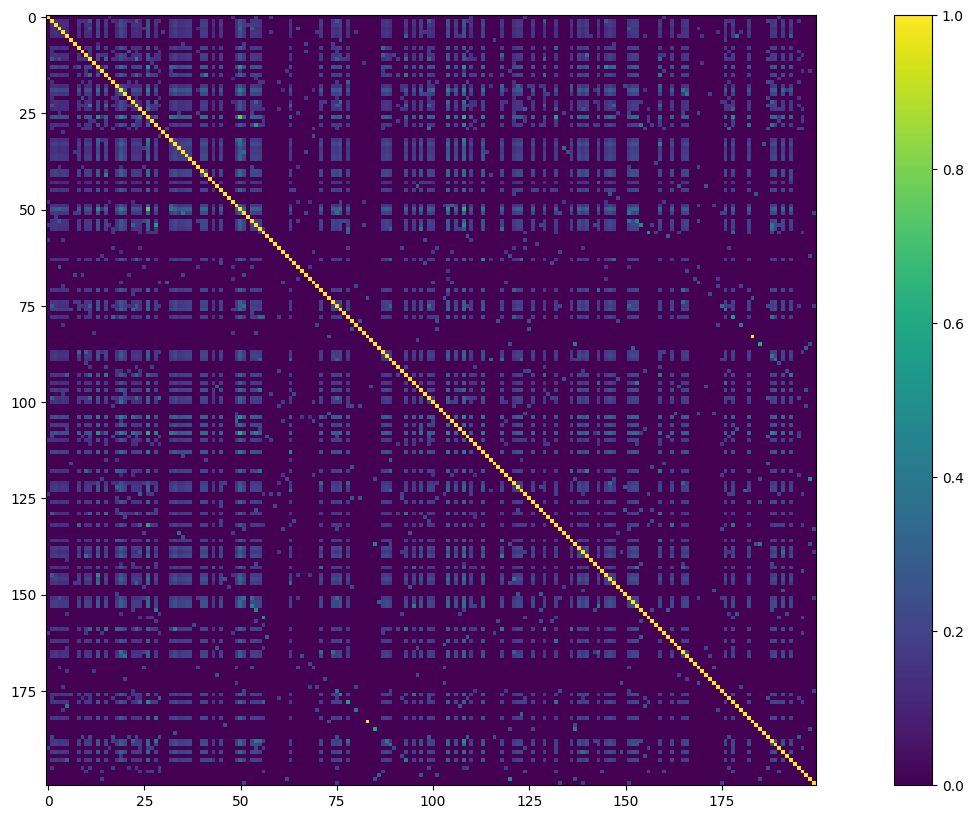

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt.imshow(salida)
plt.colorbar()

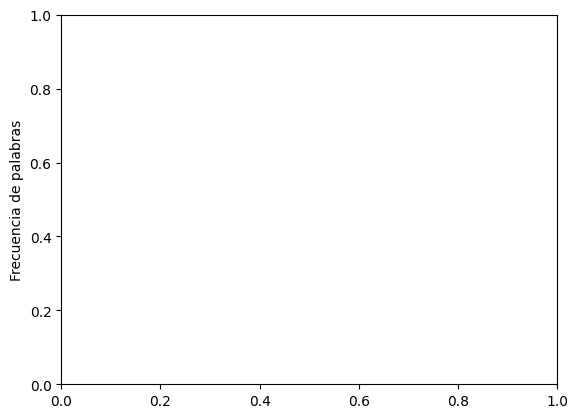

In [34]:
plt.ylabel(blabla)
plt.show()